Total de emails: 33716
Distribuição de classes:
Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

Total após remover mensagens vazias: 33664

Distribuição do número de palavras por email:
count    33664.000000
mean       358.054836
std        839.037997
min          1.000000
25%        151.000000
50%        185.000000
75%        355.000000
max      45448.000000
Name: word_count, dtype: float64

Emails com menos de 150 palavras: 7593 (22.6%)
Emails com 150 palavras ou mais: 26071 (77.4%)


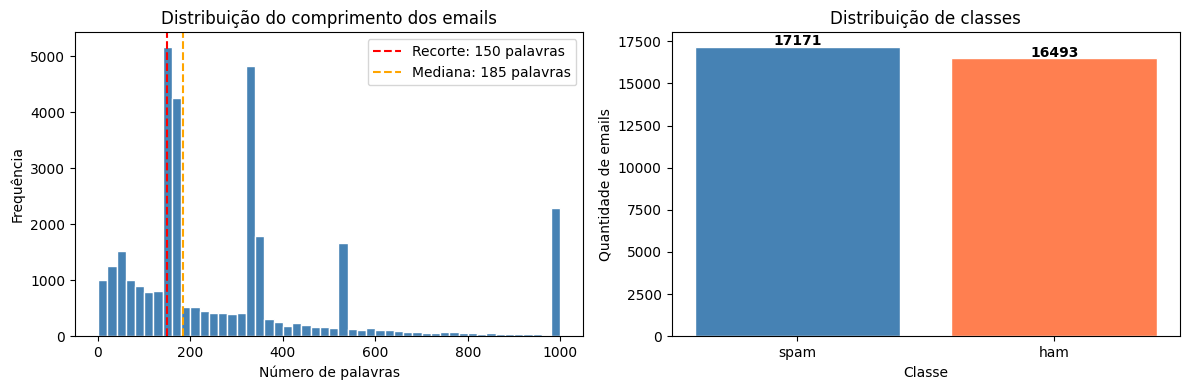

Figura salva em: /home/edson-luiz/Projetos/TCC/figures/exploratory_analysis.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'figures'

FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / 'enron_spam_data.csv')
print(f"Total de emails: {len(df)}")
print(f"Distribuição de classes:\n{df['Spam/Ham'].value_counts()}")
print()

df = df.dropna(subset=['Message'])
print(f"Total após remover mensagens vazias: {len(df)}")
print()

df['word_count'] = df['Message'].str.split().str.len()
print("Distribuição do número de palavras por email:")
print(df['word_count'].describe())
print()

abaixo_150 = (df['word_count'] < 150).sum()
acima_150 = (df['word_count'] >= 150).sum()
print(f"Emails com menos de 150 palavras: {abaixo_150} ({abaixo_150/len(df)*100:.1f}%)")
print(f"Emails com 150 palavras ou mais: {acima_150} ({acima_150/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['word_count'].clip(upper=1000), bins=50,
             color='steelblue', edgecolor='white')
axes[0].axvline(x=150, color='red', linestyle='--',
                label='Recorte: 150 palavras')
axes[0].axvline(x=df['word_count'].median(), color='orange',
                linestyle='--', label=f"Mediana: {int(df['word_count'].median())} palavras")
axes[0].set_title('Distribuição do comprimento dos emails')
axes[0].set_xlabel('Número de palavras')
axes[0].set_ylabel('Frequência')
axes[0].legend()

class_counts = df['Spam/Ham'].value_counts()
axes[1].bar(class_counts.index, class_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Distribuição de classes')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Quantidade de emails')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figura salva em: {FIGURES_DIR / 'exploratory_analysis.png'}")